# Stage 3. Multiplicative LoRA, rank sweep
### CB1 (six-class) | Gemma-2-9B-it | W = W(I + UV)

Sweeps the adapter rank over r in {4, 8, 16, 32} with the rank selected on the **validation**
partition, and measures the rank-preservation conditions of Proposition 2 directly at every rank:
the spectral norm of UV, the smallest singular value of I + UV, its condition number, and the
thresholded effective rank.

**Reported in:** Sec. 4.4 and Sec. 4.9 of the paper, the S3 column of Table 3, and Table 8.

**Protocol.** Identical to Stage 2, so the two are directly comparable.

**Result.** Validation selects r = 32, giving a test Macro F1 of 0.8972 with 39,911,424
trainable parameters.

**How to run.** Run Step 1, restart the runtime, then run the remaining steps in order.

In [2]:
# ── Environment and protocol notes ────────────────────────────────────────────
# Pins changed for the same reasons as Stages 2 and 4:
#   datasets<4.0.0   : datasets 4.0 imports VideoReader from torchvision.io,
#                      which no longer exists in torchvision 0.26.
#   transformers cap : below 4.52, where the kwarg is still torch_dtype and the
#                      float8_e8m0fnu problem does not arise.
#   torchvision / numpy / pandas pins removed: they no longer resolve on
#                      Python 3.13 and pip aborts the WHOLE command if one fails.
# ─────────────────────────────────────────────────────────────────────────────
!pip install -q \
    "transformers>=4.47.0,<4.52.0" \
    "peft>=0.14.0" \
    "bitsandbytes>=0.45.0" \
    "accelerate>=1.2.0" \
    "datasets>=3.0.0,<4.0.0" \
    scikit-learn tqdm matplotlib seaborn

import importlib.metadata as md
for p in ['torch','transformers','peft','bitsandbytes','accelerate','datasets','numpy','pandas']:
    try:    print(f'  {p:16s} {md.version(p)}')
    except Exception: print(f'  {p:16s} NOT INSTALLED')

print()
print('='*62)
print('  ACTION REQUIRED: Runtime -> Restart session, NOW.')
print('  Then run from Step 2 onwards. Do NOT re-run this cell.')
print('  Check above: transformers must be 4.51.x and datasets 3.x.')
print('='*62)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 106.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.24.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is incompatible.
  torch            2.11.0+cu128
  transformers     4.51.3
  peft             0.20.0
  bitsandbytes     0.50.1
  accelerate       1.14.0
  datasets         3.6.0
  numpy            2.1.3
  pandas           2.2.3

  ACTION REQUIRED: Runtime -> Restart session, NOW.
  Then run from Step 2 onwards. Do NOT re-run this

---
## Step 2: Import Libraries and Initial Setup

**Purpose**: Import all modules, set random seeds, load HF token, mount Drive.
**Identical to Stage 2** — only the stage label in print statements differs.
HF token loaded from Colab Secrets (key: `HF_TOKEN`) — same as Stage 2.


In [1]:
# guard against the datasets/torchvision VideoReader clash ────────
try:
    import datasets, datasets.config
    datasets.config.TORCHVISION_AVAILABLE = False
except Exception as _e:
    print('torchvision guard skipped:', _e)
# ─────────────────────────────────────────────────────────────────────────────
import os
import random
import collections
import re
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    matthews_corrcoef,
)

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    TrainerCallback,
)
from peft import prepare_model_for_kbit_training, LoraConfig, get_peft_model
# NOTE: LoraConfig + get_peft_model are used in Stage 3 as a PEFT registration shell.
# Transformers Trainer (>=4.47) checks _is_peft_model() and rejects purely quantised models.
# We register the model as a PEFT model first (so the check passes), then replace
# the PEFT LoRA layers with our custom MultiplicativeLoRALayer.

import bitsandbytes.functional as bnb_F

from google.colab import drive, userdata

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_all_seeds(seed: int = 42):
    """Fix all random seeds for fully reproducible training."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

# ── HuggingFace token ────────────────────────────────────────────────────────
# google/gemma-2-9b-it requires an HF token (gated model).
def load_hf_token() -> str:
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add it via Colab Secrets (key icon in sidebar).")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()

# ── Mount Google Drive ───────────────────────────────────────────────────────
drive.mount('/content/drive')
print("✓ Google Drive mounted.")

# ── GPU check ────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Purpose**: All hyperparameters and settings in one place.
**Changes from Stage 2:**
- `RANK_SWEEP` now = `[4, 8, 32]` — r=16 is NOT included (run in Step 12, merged in Step 13)
- `OUTPUT_DIR` updated to Stage 3 path
- Formula label updated to `Wf = W(I + UV)`
- Everything else is **identical to Stage 2**


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION — Stage 3a: Multiplicative LoRA | CB1 | Gemma-2-9B-IT
# ════════════════════════════════════════════════════════════════════════════

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME   = "google/gemma-2-9b-it"
# HF token required — gated model. Add HF_TOKEN to Colab Secrets.
NUM_LABELS   = 6
MAX_LENGTH   = 256

# ── Gemma-2 system role workaround ────────────────────────────────────────────
# Gemma-2 does NOT support a system role in its chat template.
# The system prompt is prepended directly to the first user turn as plain text.
# This matches the Stage 2 Gemma-2-9B implementation exactly.
_SYSTEM_PREFIX = (
    "You are a cyberbullying detection classifier. "
    "Classify the tweet into one of 6 categories: "
    "not_cyberbullying, gender, religion, other_cyberbullying, age, ethnicity. "
    "Respond with ONLY the category label, nothing else.\n\n"
)

# ── LoRA (Multiplicative) ─────────────────────────────────────────────────────
LORA_RANK    = 16           # Default rank for Step 12
LORA_ALPHA   = 16           # Always equals LORA_RANK → scaling = 1.0
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']

# Stage 3 rank sweep: r=16 already run in Step 12 — NOT repeated here
RANK_SWEEP   = [4, 8, 16, 32]   # r=16 now run inside the sweep, Step 12 disabled

# ── Training ──────────────────────────────────────────────────────────────────
NUM_EPOCHS          = 1     # Single epoch — protocol requirement
LEARNING_RATE       = 2e-4
TRAIN_BATCH_SIZE    = 8     # Attempting batch=8 (was 4 in Stage 2 CB1 — monitor for OOM)
EVAL_BATCH_SIZE     = 8
WEIGHT_DECAY        = 0.01
EVAL_STEPS          = 200
LOGGING_STEPS       = 50
OUTPUT_DIR          = "/content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Gemma2_9B"

# ── Dataset & Split ───────────────────────────────────────────────────────────
CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

# ── Label mapping ─────────────────────────────────────────────────────────────
LABEL_MAPPING = {
    'not_cyberbullying':   0,
    'gender':              1,
    'religion':            2,
    'ethnicity':           3,
    'age':                 4,
    'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Stage    : 3a — Multiplicative LoRA")
print(f"  Formula  : Wf = W(I + UV)   [L2 = 0]")
print(f"  Model    : {MODEL_NAME}")
print(f"  HF token : Required (gated model)")
print(f"  Gemma-2  : No system role → _SYSTEM_PREFIX workaround active")
print(f"  LoRA rank: {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Batch    : train={TRAIN_BATCH_SIZE} | eval={EVAL_BATCH_SIZE}  (attempting batch=8 — was 4 in Stage 2 CB1)")
print(f"  OOM note : If CUDA OOM occurs, reduce TRAIN_BATCH_SIZE to 4 and restart from Step 12")
print(f"  Epochs   : {NUM_EPOCHS}  (single-epoch protocol)")
print(f"  Rank sweep (Step 13): {RANK_SWEEP}  [r=16 from Step 12 — not repeated]")
print(f"\n  Stage 2 Gemma-2-9B CB1 reference (best model in Stage 2 — first to cross 0.90):")
print(f"  r=4: F1=0.8951 | r=8: F1=0.8954 | r=16: F1=0.8986 | r=32: F1=0.9010 ★")
print(f"  Eff.Rank Wf: 2815.98 (perfectly constant across all r)")
print(f"  → Stage 2 Gemma-2-9B was the best CB1 model. Stage 3 must match or beat 0.9010.")
print(f"\n  Key Stage 2 finding: Gemma-2 ICL interference — well-aligned model hurt by few-shot.")
print(f"  This is NOT expected to affect LoRA fine-tuning — ICL interference is prompt-based.")


✓ Configuration loaded.
  Stage    : 3a — Multiplicative LoRA
  Formula  : Wf = W(I + UV)   [L2 = 0]
  Model    : google/gemma-2-9b-it
  HF token : Required (gated model)
  Gemma-2  : No system role → _SYSTEM_PREFIX workaround active
  LoRA rank: 16  |  alpha: 16  |  scaling: 1.0
  Batch    : train=8 | eval=8  (attempting batch=8 — was 4 in Stage 2 CB1)
  OOM note : If CUDA OOM occurs, reduce TRAIN_BATCH_SIZE to 4 and restart from Step 12
  Epochs   : 1  (single-epoch protocol)
  Rank sweep (Step 13): [4, 8, 16, 32]  [r=16 from Step 12 — not repeated]

  Stage 2 Gemma-2-9B CB1 reference (best model in Stage 2 — first to cross 0.90):
  r=4: F1=0.8951 | r=8: F1=0.8954 | r=16: F1=0.8986 | r=32: F1=0.9010 ★
  Eff.Rank Wf: 2815.98 (perfectly constant across all r)
  → Stage 2 Gemma-2-9B was the best CB1 model. Stage 3 must match or beat 0.9010.

  Key Stage 2 finding: Gemma-2 ICL interference — well-aligned model hurt by few-shot.
  This is NOT expected to affect LoRA fine-tuning — ICL inte

---
## Step 4: Text Preprocessing

**Purpose**: Define LLM-optimised preprocessing for raw tweet text.
**Identical to Stage 2** — copied verbatim. The same preprocessing must be applied to
guarantee that the train/test split produces exactly the same samples as Stage 2,
making cross-stage comparisons valid.


In [3]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    """LLM-optimised tweet preprocessing — identical to Stage 2."""
    if not isinstance(text, str):
        return ""

    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags:
        text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis:
        text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3:
        return ""
    return text

# ── Quick sanity check ───────────────────────────────────────────────────────
test_tweet = "RT @user123: Check this out http://example.com !!! @someone is so dumb"
print("Before:", test_tweet)
print("After: ", preprocess_text_for_llm(test_tweet))
print("\n✓ Preprocessing function defined.")


Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

**Purpose**: Load `cb1.csv`, apply all cleaning steps.
**Columns**: `tweet_text` | `cyberbullying_type`
**Identical to Stage 2** — same cleaning pipeline ensures identical post-cleaning dataset,
which is required so that the 75/25 split (seeded at 42) produces the same train/test sets.


In [4]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")

df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})
print(f"[2] Columns renamed: {df.columns.tolist()}")

corrupt_mask = df['text'].astype(str).str.strip().isin(
    ['#NAME?', '#REF!', '#VALUE!', '#N/A', 'nan', ''])
n_corrupt = corrupt_mask.sum()
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[3] Removed {n_corrupt} corrupt rows → {len(df):,} remaining")

df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[4] After preprocessing: {len(df):,} remaining")

text_label_counts = df.groupby('text')['label'].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
n_conflicting     = df['text'].isin(conflicting_texts).sum()
df = df[~df['text'].isin(conflicting_texts)].reset_index(drop=True)
print(f"[5] Removed {n_conflicting:,} annotation-conflict rows → {len(df):,} remaining")

before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")

before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[7] Removed {before - len(df):,} short texts → {len(df):,} remaining")

unknown_labels = set(df['label'].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown_labels) == 0, f"Unknown labels: {unknown_labels}"

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
imbalance = counts.max() / counts.min()
print(f"\n  Imbalance ratio : {imbalance:.2f}×")
print("  Primary metric  : Macro F1  |  Secondary: MCC")


════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[2] Columns renamed: ['text', 'label']
[3] Removed 0 corrupt rows → 47,692 remaining
[4] After preprocessing: 46,942 remaining
[5] Removed 3,250 annotation-conflict rows → 43,692 remaining
[6] Removed 358 exact duplicates → 43,334 remaining
[7] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio : 1.37×
  Primary metric  : Macro F1  |  Secondary:

---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

**Purpose**: Split dataset into train / val / test.
**Identical to Stage 2** — same split protocol with seed=42 guarantees the exact same
test set as Stage 2, making cross-stage F1 comparisons valid.

Protocol:
- Primary split: 75% train+val / 25% test (stratified, seed=42)
- Near-duplicate check: TF-IDF cosine @0.90 — near-dups moved from test → train
- Validation carved: 10% of train portion → Trainer's eval_dataset
- Test set: touched exactly once per rank (at Step 12 / Step 13 evaluation)


In [5]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

# ── Step 6a: Primary stratified split ────────────────────────────────────────
train_val_df, test_df = train_test_split(
    df,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    stratify=df['label']
)
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
print(f"    ({len(train_val_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%)")

# ── Step 6b: Near-duplicate leakage check ────────────────────────────────────
print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")

all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
batch_size     = 500
for start in range(0, len(test_df), batch_size):
    end         = min(start + batch_size, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    max_sims    = batch_sims.max(axis=1)
    leaked_mask = max_sims >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")

if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df        = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df   = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train+val → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

# ── Step 6c: Data leakage assertion ──────────────────────────────────────────
overlap = set(train_val_df['text'].tolist()).intersection(set(test_df['text'].tolist()))
assert len(overlap) == 0, f"DATA LEAKAGE DETECTED: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed — zero train/test overlap.")

# ── Step 6d: Carve validation set from train portion ─────────────────────────
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_FROM_TRAIN,
    random_state=RANDOM_STATE,
    stratify=train_val_df['label']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\n[3] Validation carved → Train: {len(train_df):,} | Val: {len(val_df):,}")

# ── Step 6e: Final statistics ─────────────────────────────────────────────────
print("\n" + "═" * 60)
print("FINAL SPLIT STATISTICS")
print("═" * 60)
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct = len(split_df) / len(df) * 100
    print(f"\n{name} ({len(split_df):,} samples, {pct:.1f}% of total):")
    for label, count in split_df['label'].value_counts().sort_index().items():
        print(f"  {label:<25} {count:>5}  ({count/len(split_df)*100:.1f}%)")

print(f"\n  ✓ Protocol check: test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")


════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834
    (75.0% / 25.0%)

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved to train+val → Train+Val: 33,004 | Test: 10,330

    ✓ Data leakage assertion passed — zero train/test overlap.

[3] Validation carved → Train: 29,703 | Val: 3,301

════════════════════════════════════════════════════════════
FINAL SPLIT STATISTICS
════════════════════════════════════════════════════════════

Train (29,703 samples, 68.5% of total):
  age                        5420  (18.2%)
  ethnicity                  5497  (18.5%)
  gender                     5149  (17.3%)
  not_cyberbullying          4235  (14.3%)
  other_cyberbullying        3995  (13.4%)
  religion                   5407  (18.2%)

Validation (3,301 samples, 7.6% of total):
  

---
## Step 7: Helper Functions — Class Weights

**Purpose**: Compute inverse-frequency class weights for the loss function.
**Identical to Stage 2** — same function, same call site.


In [6]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    """Compute inverse-frequency class weights from training labels."""
    counts  = df[label_col].value_counts()
    total   = len(df)
    n_classes = len(LABEL_MAPPING)
    weights = [total / (n_classes * counts.get(ID2LABEL[i], 1)) for i in range(n_classes)]
    weights_norm = [w / sum(weights) * n_classes for w in weights]
    print("Class weights (inverse-frequency, normalised):")
    for i, (cls, w) in enumerate(zip(TARGET_NAMES, weights_norm)):
        print(f"  [{i}] {cls:<25} {w:.4f}")
    return weights_norm

print("✓ get_class_weights() defined.")


✓ get_class_weights() defined.


---
## Step 8: Effective Rank Computation — Multiplicative LoRA

**Purpose**: Compute effective rank of the full adapted weight **Wf = W(I + UV) = W + W@(UV)**.

**Key change from Stage 2:**
- Stage 2: SVD on `Wf = W + ΔW` where `ΔW = B @ A`
- Stage 3: SVD on `Wf = W + W @ (U @ V)` — same principle, different adapter reconstruction

**What stays identical:**
- W is dequantised from 4-bit NF4 via `bnb_F.dequantize_4bit()` (same Bug1 fix as Stage 2)
- SVD threshold: `threshold_ratio = 1e-3` of max singular value
- Reports `avg_eff_rank_Wf` (full weight) and `avg_eff_rank_UV` (adapter only, for reference)
- Measured on target layers only (`q_proj`, `k_proj`, `v_proj`, `o_proj`)

**Research question**: Does `eff_rank(Wf)` remain constant across r ∈ {4, 8, 16, 32}?
Stage 2 confirmed constant eff. rank for additive LoRA (Proposition 1).
Stage 3 tests whether this holds for multiplicative LoRA (Proposition 3: if I+UV invertible → constant).


In [7]:
def calculate_effective_rank_multiplicative(model: nn.Module,
                                             threshold_ratio: float = 1e-3) -> Dict[str, float]:
    """
    Compute effective rank of Wf = W(I + UV) = W + W @ (UV).

    Walks the model and finds all MultiplicativeLoRALayer instances.
    Reconstructs Wf by dequantising W from 4-bit NF4 and computing W + W@(UV).
    SVD threshold: 0.1% of max singular value (consistent with Stage 2).

    Returns avg_eff_rank_Wf (full weight), avg_eff_rank_UV (adapter only, reference).
    """
    full_ranks = []
    uv_ranks   = []
    per_layer  = []
    skipped    = 0

    for name, module in model.named_modules():
        if not isinstance(module, MultiplicativeLoRALayer):
            continue
        try:
            # Reconstruct UV from trainable parameters
            U  = module.lora_U.data.float()   # (n × r)
            V  = module.lora_V.data.float()   # (r × n)
            UV = U @ V                         # (n × n)

            # Effective rank of UV alone (reference — analogous to Stage 2's ΔW rank)
            S_uv = torch.linalg.svdvals(UV)
            r_uv = int((S_uv > threshold_ratio * S_uv[0]).sum()) if S_uv[0] > 0 else 0
            uv_ranks.append(r_uv)

            # Dequantise W from 4-bit NF4 (module.inner is the actual Linear4bit)
            weight_obj = module.inner.weight
            if hasattr(weight_obj, 'quant_state'):
                try:
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                except Exception as e:
                    skipped += 1
                    continue
            else:
                W = weight_obj.data.float()

            # Handle transpose if needed (weight stored as (out, in))
            if W.shape[1] != UV.shape[0]:
                if W.T.shape[1] == UV.shape[0]:
                    W = W.T.contiguous()
                else:
                    skipped += 1
                    continue

            # Wf = W + W @ UV  (equivalent to W(I + UV))
            Wf   = W + W @ UV
            S_Wf = torch.linalg.svdvals(Wf)
            r_Wf = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0

            full_ranks.append(r_Wf)
            per_layer.append({'layer': name, 'rank_Wf': r_Wf, 'rank_UV': r_uv})

        except Exception as e:
            skipped += 1
            continue

    if skipped > 0:
        print(f"  ℹ {skipped} layers skipped during eff. rank computation")
    if not full_ranks:
        print("  ⚠ No MultiplicativeLoRALayer found — check model structure")

    return {
        "avg_eff_rank_Wf": float(np.mean(full_ranks)) if full_ranks else 0.0,
        "avg_eff_rank_UV": float(np.mean(uv_ranks))   if uv_ranks   else 0.0,
        "layer_count":     len(full_ranks),
        "per_layer_ranks": per_layer,
    }

print("✓ calculate_effective_rank_multiplicative() defined.")
print("  SVD on Wf = W + W@(UV)  — NOT on UV alone.")
print("  Uses module.inner (unwrapped Linear4bit) for dequantisation.")
print("  Consistent with Stage 2 Bug1 fix: eff. rank of full Wf, not adapter.")


✓ calculate_effective_rank_multiplicative() defined.
  SVD on Wf = W + W@(UV)  — NOT on UV alone.
  Uses module.inner (unwrapped Linear4bit) for dequantisation.
  Consistent with Stage 2 Bug1 fix: eff. rank of full Wf, not adapter.


---
## Step 9: Evaluation Metrics

**Purpose**: Define all metric functions used during training and final evaluation.
**Identical to Stage 2** — `compute_metrics()`, `evaluate_dataset()`, and `make_predictions()`
are copied verbatim. The primary metric is Macro F1; secondary is MCC.


In [8]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    """Called by the Trainer at every eval_steps."""
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true: List[int],
                     y_pred: List[int],
                     dataset_name: str) -> Dict[str, float]:
    """Full evaluation report: per-class F1, MCC, confusion matrices."""
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")

    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)

    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")

    print(f"\n  Classification Report:")
    report = classification_report(
        y_true, y_pred,
        labels=list(range(NUM_LABELS)),
        target_names=TARGET_NAMES,
        zero_division=0, digits=4
    )
    print(report)

    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}', fontsize=12)
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised)\n{dataset_name}', fontsize=12)
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'accuracy': accuracy, 'macro_f1': macro_f1,
        'weighted_f1': weighted_f1, 'balanced_accuracy': bal_accuracy, 'mcc': mcc,
    }


def make_predictions(model, df_test, tokenizer, batch_size=32):
    """Run batched inference on test DataFrame. Returns df with 'predictions' column."""
    model.eval()
    all_preds = []
    texts     = df_test['text'].tolist()

    for start in range(0, len(texts), batch_size):
        batch_texts = texts[start:start + batch_size]
        enc = tokenizer(
            batch_texts, padding='max_length', truncation=True,
            max_length=MAX_LENGTH, return_tensors='pt'
        ).to(model.device)
        with torch.no_grad():
            logits = model(**enc).logits
        preds = torch.argmax(logits, dim=-1).cpu().numpy()
        all_preds.extend(preds.tolist())

    df_out = df_test.copy()
    df_out['predictions'] = [ID2LABEL[p] if isinstance(df_test['label'].iloc[0], str)
                             else p for p in all_preds]
    # Ensure integer labels for metrics
    if isinstance(df_test['label'].iloc[0], str):
        df_out['label'] = df_out['label'].map(LABEL_MAPPING)
        df_out['predictions'] = df_out['predictions'].map(LABEL_MAPPING)
    return df_out


print("✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.")


✓ compute_metrics(), evaluate_dataset(), make_predictions() defined.


---
## Step 10: Training Stability System + Custom Trainer

**Purpose**: StabilityCallback (2-panel, single-epoch protocol) + class-weighted CustomTrainer.
**Identical to Stage 2** — copied verbatim. The stability system must be identical across
stages so that the cross-stage comparison in Step 14 is valid.

Includes `plot_cross_stage_stability()` — run after all three stages complete.


In [9]:
import matplotlib.gridspec as gridspec

class StabilityCallback(TrainerCallback):
    """
    2-dimension stability tracking (single-epoch protocol).
    Dimension 1 — Loss stability   : std dev & CV across training steps
    Dimension 2 — Metric stability : std dev of val F1 & MCC across eval checkpoints
    Panels 3 & 4 (grad norm / per-epoch) omitted — uninformative with 1 epoch.
    """
    def __init__(self):
        self.train_losses = []
        self.val_metrics  = collections.defaultdict(list)
        self.val_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0:
            return
        if 'loss' in logs:
            self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics:
            return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            self.val_metrics[key.replace('eval_', '')].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr) / np.mean(arr)) if np.mean(arr) > 0 else 0.0
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max() - arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])
        loss_cv = report.get('loss_cv_overall', 0.0)
        f1_std  = report.get('val_f1_std', 0.0)
        report['stability_score'] = round((loss_cv * 0.5) + (f1_std * 0.5), 6)
        return report

    def plot_stability_curves(self, stage_label: str = 'Stage 3', save_path: str = None):
        """2-panel: Training loss curve + Validation F1 & MCC."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        if self.train_losses:
            steps  = [s for (s, _) in self.train_losses]
            losses = [l for (_, l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7, alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy', linewidth=2.2,
                         label=f'Rolling mean (w={window})')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)
            ax1.set_xlabel('Global Step'); ax1.set_ylabel('Cross-Entropy Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen',
                         linewidth=2, markersize=5, label='Macro F1')
                f1_mean = float(np.mean(f1_vals)); f1_std = float(np.std(f1_vals))
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':', linewidth=1.2, alpha=0.6)
                ax2.fill_between(self.val_steps,
                                 [f1_mean - f1_std]*len(self.val_steps),
                                 [f1_mean + f1_std]*len(self.val_steps),
                                 color='forestgreen', alpha=0.10, label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen', fontsize=10)
                ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2_r is not None and 'mcc' in self.val_metrics:
                ax2_r.plot(self.val_steps, self.val_metrics['mcc'], 's--', color='darkorange',
                           linewidth=2, markersize=5, label='MCC')
                ax2_r.set_ylabel('MCC', color='darkorange', fontsize=10)
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
                lines1, lbl1 = ax2.get_legend_handles_labels()
                lines2, lbl2 = ax2_r.get_legend_handles_labels()
                ax2.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='lower right')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)
            ax2.set_xlabel('Global Step'); ax2.grid(True, alpha=0.3)

        plt.suptitle(f'Training Stability Analysis — {stage_label}',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'  ✓ Stability plot saved → {save_path}')
        plt.show()


class CustomTrainer(Trainer):
    """Extends Trainer with class-weighted cross-entropy loss — identical to Stage 2."""
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
            if class_weights is not None else None
        )

    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels  = inputs.pop('labels').long()
        outputs = model(**inputs)
        loss    = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss


def plot_cross_stage_stability(stage_reports: Dict[str, Dict], save_path: str = None):
    """Side-by-side stability comparison across Stages 2, 3, 4. Run after all stages complete."""
    labels  = list(stage_reports.keys())
    n       = len(labels)
    colours = ['#2E75B6', '#2E86AB', '#1B998B', '#F4A261'][:n]
    metrics_map = {
        'Loss Std Dev\n(Overall)':              'loss_std_overall',
        'Loss CV\n(Coeff. of Variation)':       'loss_cv_overall',
        'Val F1 Std Dev\n(Across Checkpoints)': 'val_f1_std',
        'Composite\nStability Score':           'stability_score',
    }
    fig, axes = plt.subplots(1, len(metrics_map), figsize=(5.5 * len(metrics_map), 6))
    for ax, (metric_label, metric_key) in zip(axes, metrics_map.items()):
        values = [stage_reports[lbl].get(metric_key, 0.0) or 0.0 for lbl in labels]
        bars   = ax.bar(range(n), values, color=colours, alpha=0.85,
                        edgecolor='white', linewidth=1.5, width=0.6)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(values + [1e-9]) * 0.03,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(metric_label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value  (lower = more stable)', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    plt.suptitle(
        'Cross-Stage Training Stability Comparison\n'
        'CB1 — 6-Class Cyberbullying | meta-llama/Llama-3.2-3B-Instruct',
        fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  ✓ Cross-stage stability plot saved → {save_path}')
    plt.show()

print('✓ StabilityCallback (2-panel, single-epoch protocol) defined.')
print('✓ CustomTrainer (class-weighted cross-entropy) defined.')
print('✓ plot_cross_stage_stability() defined.')


✓ StabilityCallback (2-panel, single-epoch protocol) defined.
✓ CustomTrainer (class-weighted cross-entropy) defined.
✓ plot_cross_stage_stability() defined.


---
## Step 11: Multiplicative LoRA Adapter + Training Function

**Purpose**: Define `MultiplicativeLoRALayer` and `run_multiplicative_lora()`.
**This is the only step that materially differs from Stage 2.**

### Why the PEFT shell strategy?

Transformers Trainer (≥4.47) calls `validate_quantization_for_training()` which checks
`_is_peft_model(model)`. If the model is 4-bit quantised but not wrapped by PEFT, it raises:
`ValueError: You cannot perform fine-tuning on purely quantised models.`

Since our multiplicative adapter is custom (not a PEFT adapter type), we use a two-step approach:

1. **Register the model as a PEFT model** via `get_peft_model(model, LoraConfig(...))` —
   this sets the internal PEFT flag and satisfies the Trainer check. Standard PEFT additive
   LoRA layers (W + AB) are created at this point.
2. **Replace every PEFT LoraLayer with `MultiplicativeLoRALayer`** — our custom multiplicative
   adapter overwrites the additive ones. The model remains flagged as a PEFT model (flag is on
   the model object, not on individual layers), so the Trainer check still passes.

Net result: the Trainer sees a valid PEFT model; training computes `Wf = W(I + UV)`.

### MultiplicativeLoRALayer

Wraps each frozen 4-bit linear layer with trainable U and V:
- `U ∈ ℝⁿˣʳ` — small Gaussian init (`std=0.01`)
- `V ∈ ℝʳˣⁿ` — zero init → UV = 0 at start → Wf = W at init (safe)
- Forward: `y = W·x + W·(U·(V·x))` — efficient: V@x costs O(n·r) before hitting W
- Scaling: `alpha / rank = 1.0` (always, since `alpha = rank`)
- Dropout applied to the adapter path only

### Effective rank computation

SVD on the **reconstructed full matrix** Wf = W + W@(UV):
- W dequantised from 4-bit NF4 via `bnb_F.dequantize_4bit()` (same as Stage 2)
- UV computed from current U, V parameters
- Effective rank = singular values above 0.1% of max singular value
- Measures eff. rank of **Wf**, not of UV — consistent with Stage 2 and Proposition 1


In [10]:
import bitsandbytes as bnb

# ════════════════════════════════════════════════════════════════════════════
# MultiplicativeLoRALayer — custom adapter for Wf = W(I + UV)
# ════════════════════════════════════════════════════════════════════════════

class MultiplicativeLoRALayer(nn.Module):
    """
    Wraps a frozen 4-bit linear layer with a multiplicative LoRA adapter.

    Formula: Wf = W(I + UV)
    Forward: y = W·x + W·(U·(V·x))

    U ∈ ℝ^(n×r) : small Gaussian init (std=0.01)
    V ∈ ℝ^(r×n) : zero init → UV=0 at start → Wf=W at initialisation
    scaling = alpha / rank = 1.0 (always, since alpha = rank)

    Preserves the original layer's interface so PEFT's LoraLayer wrapper
    is replaced cleanly without breaking the model's forward pass.
    """
    def __init__(self, base_layer: nn.Module, rank: int, dropout: float = 0.05, alpha: int = None):
        super().__init__()
        self.base_layer = base_layer
        self.rank       = rank
        self.alpha      = alpha if alpha is not None else rank
        self.scaling    = self.alpha / self.rank   # = 1.0 when alpha == rank

        # Determine in_features (n) from the base layer
        # The base_layer here may be a PEFT LoraLayer wrapping a Linear4bit —
        # we unwrap to get the underlying quantised weight's in_features.
        if hasattr(base_layer, 'base_layer'):
            # PEFT wraps as: LoraLayer → base_layer → actual Linear4bit
            inner = base_layer.base_layer
        else:
            inner = base_layer

        if hasattr(inner, 'in_features'):
            n = inner.in_features
        elif hasattr(inner, 'weight'):
            n = inner.weight.shape[1]
        else:
            raise ValueError(f"Cannot determine in_features from {type(inner)}")
        self.n = n
        self.inner = inner  # keep reference to the actual quantised layer for forward

        # Trainable parameters
        self.lora_U = nn.Parameter(torch.empty(n, rank))   # (n × r)
        self.lora_V = nn.Parameter(torch.zeros(rank, n))   # (r × n) — zero init

        # U: small Gaussian; V: zero → UV=0 at start → Wf=W at init (safe)
        nn.init.normal_(self.lora_U, mean=0.0, std=0.01)

        self.dropout = nn.Dropout(p=dropout) if dropout > 0.0 else nn.Identity()

        # Freeze the inner (quantised) layer
        for param in self.inner.parameters():
            param.requires_grad = False

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Standard path: W @ x  (through the frozen 4-bit layer)
        base_out = self.inner(x)

        # Multiplicative adapter path: W @ (U @ (V @ x))
        # Step 1: V @ x  →  (..., r)
        # Step 2: U @ result  →  (..., n=in_features)
        # Step 3: W @ result  →  (..., out_features)  through frozen W
        x_drop   = self.dropout(x)
        lora_vx  = x_drop @ self.lora_V.T       # (..., r)
        lora_uvx = lora_vx @ self.lora_U.T       # (..., n)
        lora_out = self.inner(lora_uvx)          # (..., out_features)

        return base_out + self.scaling * lora_out


def apply_multiplicative_lora_over_peft(model, target_modules, rank, dropout=0.05, alpha=None):
    """
    Replace PEFT LoraLayer wrappers with MultiplicativeLoRALayer.

    Strategy:
      1. Model is already a PEFT model (registered via get_peft_model).
         This satisfies Transformers Trainer's _is_peft_model() check.
      2. We walk the named modules and replace every LoraLayer (created by PEFT)
         at the target module positions with our MultiplicativeLoRALayer.
      3. Result: model is still a PEFT model (check passes) but all trainable
         computation is our custom multiplicative adapter, not PEFT's additive one.

    Returns (model, trainable_param_count, total_param_count).
    """
    from peft.tuners.lora import LoraLayer

    if alpha is None:
        alpha = rank

    replaced = 0
    module_dict = dict(model.named_modules())

    for name, module in list(model.named_modules()):
        # Target: PEFT LoraLayer instances at our target module positions
        if not isinstance(module, LoraLayer):
            continue
        is_target = any(name.endswith(f'.{t}') or name == t for t in target_modules)
        if not is_target:
            continue

        # Get parent and attribute name
        parts = name.rsplit('.', 1)
        if len(parts) == 2:
            parent_name, attr_name = parts
            parent = module_dict.get(parent_name)
            if parent is None:
                continue
        else:
            parent    = model
            attr_name = name

        # Replace the PEFT LoraLayer with our MultiplicativeLoRALayer
        new_layer = MultiplicativeLoRALayer(
            base_layer=module,   # pass the whole PEFT LoraLayer — we unwrap inside __init__
            rank=rank,
            dropout=dropout,
            alpha=alpha
        )
        setattr(parent, attr_name, new_layer)
        replaced += 1

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Replaced {replaced} PEFT LoraLayers → MultiplicativeLoRALayer (rank={rank}, alpha={alpha})")
    print(f"  Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)")
    return model, trainable, total


# ════════════════════════════════════════════════════════════════════════════
# run_multiplicative_lora() — mirrors run_standard_lora() with adapter swap
# ════════════════════════════════════════════════════════════════════════════

def run_multiplicative_lora(
    train_df:  pd.DataFrame,
    val_df:    pd.DataFrame,
    test_df:   pd.DataFrame,
    lora_rank: int,
    run_label: str = ''
) -> Dict:
    """
    Train and evaluate Multiplicative LoRA on CB1.

    Stage 3 formulation: Wf = W(I + UV)

    Mirrors run_standard_lora() from Stage 2 exactly.
    Key difference: after PEFT registration (to satisfy Trainer's _is_peft_model check),
    PEFT LoRA layers are replaced with MultiplicativeLoRALayer.
    """
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank    # scaling = alpha/rank = 1.0 always
    label      = run_label or f'MultiplicativeLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 3 — MULTIPLICATIVE LoRA  |  {label}')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Rank r  : {lora_rank}  |  Alpha: {lora_alpha}  |  Scaling: {lora_alpha/lora_rank:.1f}')
    print(f'  Formula : Wf = W(I + UV)   [L2 = 0]')
    print(f'  Epochs  : {NUM_EPOCHS}  (single-epoch protocol)')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # ── 1. Tokenizer ──────────────────────────────────────────────────────────
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    if tokenizer.pad_token is None:
        tokenizer.pad_token    = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab size: {tokenizer.vocab_size:,}')

    def tokenise(examples):
        # Gemma-2 has no system role — prepend system prompt directly to user text
        texts_with_prefix = [_SYSTEM_PREFIX + t for t in examples['text']]
        return tokenizer(texts_with_prefix,
                         padding='max_length', truncation=True, max_length=MAX_LENGTH)

    # ── 2. Label mapping and dataset preparation ──────────────────────────────
    print('[2] Mapping labels and preparing HF datasets...')
    train_m = train_df.copy()
    val_m   = val_df.copy()
    test_m  = test_df.copy()

    for split in [train_m, val_m, test_m]:
        split['label'] = split['label'].map(LABEL_MAPPING)
        assert split['label'].notnull().all(), 'Unmapped labels detected!'

    hf_train = Dataset.from_pandas(
        train_m[['text', 'label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(
        val_m[['text', 'label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch')
    hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    # ── 3. Quantisation config (4-bit NF4 — identical to Stage 2) ────────────
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    # ── 4. Load model ─────────────────────────────────────────────────────────
    print('[3] Loading model (4-bit NF4 QLoRA)...')
    # transformers renamed torch_dtype -> dtype in 4.56. We pin below
    # 4.52, where it is still torch_dtype. Try the old name, fall back to the new.
    import transformers as _tf
    _common = dict(quantization_config=quant_config, num_labels=NUM_LABELS,
                   device_map='auto', token=HF_TOKEN)
    try:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, torch_dtype=torch.bfloat16, **_common)
        print(f'   transformers {_tf.__version__}, used torch_dtype=')
    except TypeError:
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME, dtype=torch.bfloat16, **_common)
        print(f'   transformers {_tf.__version__}, used dtype=')
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache    = False
    model = prepare_model_for_kbit_training(model)

    # ── 4b. Register as PEFT model (satisfies Trainer's _is_peft_model check) ─
    # We use LoraConfig with our target modules at rank=lora_rank.
    # This creates standard PEFT LoRA layers, which we then replace in step 4c.
    print('[4] Registering PEFT shell + injecting multiplicative adapter...')
    lora_config = LoraConfig(
        r=lora_rank,
        lora_alpha=lora_alpha,
        target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT,
        bias='none',
        task_type='SEQ_CLS',
    )
    model = get_peft_model(model, lora_config)
    print(f'   PEFT shell registered. Model is now _is_peft_model=True.')

    # ── 4c. Replace PEFT LoRA layers with MultiplicativeLoRALayer ─────────────
    # The PEFT LoraLayer wrappers are removed and replaced with our custom
    # multiplicative adapter. The model remains a PEFT model (flag preserved).
    model, trainable, total = apply_multiplicative_lora_over_peft(
        model,
        target_modules=TARGET_MODULES,
        rank=lora_rank,
        dropout=LORA_DROPOUT,
        alpha=lora_alpha
    )

    # put the adapter on the same device as the frozen weights ────
    # MultiplicativeLoRALayer creates lora_U / lora_V with torch.empty / zeros,
    # which land on the CPU. In June the Trainer still called model.to(device)
    # and quietly moved them. It no longer does, because device_map='auto' has
    # already placed the model, so the forward pass hit a CPU tensor against a
    # CUDA tensor. Move them explicitly. This is bug 4 from the Stage 4 fix list.
    _moved = 0
    for _m in model.modules():
        if type(_m).__name__ != 'MultiplicativeLoRALayer':
            continue
        _dev = _m.inner.weight.device
        if _m.lora_U.device != _dev:
            _m.lora_U.data = _m.lora_U.data.to(_dev)
            _m.lora_V.data = _m.lora_V.data.to(_dev)
            _moved += 1
    print(f'   device fix: moved adapters on {_moved} layers to the frozen-weight device')
    _bad = [n_ for n_, p in model.named_parameters()
            if p.requires_grad and ('lora_U' in n_ or 'lora_V' in n_) and p.device.type != 'cuda']
    assert not _bad, f'adapter parameters still off-GPU: {_bad[:3]}'

    # parameter audit ─────────────────────────────────────────────
    # The multiplicative adapter is injected OVER a PEFT LoRA shell, and that
    # shell's lora_A / lora_B tensors keep requires_grad=True even though the
    # forward pass never touches them (it uses self.inner directly). They get no
    # gradient and stay at their initial values, so results are unaffected, but
    # they DO inflate the reported trainable count. Report both numbers.
    # Theory (Sec. 3.1.2): multiplicative adaptation uses 2*n*r parameters.
    uv_only = sum(p.numel() for _n, p in model.named_parameters()
                  if p.requires_grad and ('lora_U' in _n or 'lora_V' in _n))
    dead_ab = trainable - uv_only
    print(f'   PARAMETER AUDIT')
    print(f'     U and V (the actual adapter) : {uv_only:,}   <-- report THIS as Stage 3 params')
    print(f'     inert PEFT lora_A / lora_B   : {dead_ab:,}   (no gradient, never used in forward)')
    print(f'     counted as trainable         : {trainable:,}   (inflated, do not quote)')

    # ── 5. Training arguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=run_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='steps',
        eval_steps=EVAL_STEPS,
        logging_strategy='steps',
        logging_steps=LOGGING_STEPS,
        save_strategy='no',
        load_best_model_at_end=False,
        warmup_steps=100,
        lr_scheduler_type='cosine',
        fp16=False,
        bf16=True,
        report_to='none',
        dataloader_pin_memory=False,
    )

    # ── 6. Trainer (no EarlyStoppingCallback — 1 epoch) ──────────────────────
    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model,
        args=training_args,
        train_dataset=hf_train,
        eval_dataset=hf_val,
        compute_metrics=compute_metrics,
        class_weights=get_class_weights(train_m),
        callbacks=[stability_cb],
    )

    # ── 7. Train ──────────────────────────────────────────────────────────────
    print(f'[4] Training — {NUM_EPOCHS} epoch (single-epoch protocol)...')
    trainer.train()

    # Training time — printed immediately after train() (protocol requirement)
    train_runtime_s = trainer.state.log_history[-1].get('train_runtime', 0)
    print(f"Training time: {train_runtime_s:.0f}s ({train_runtime_s/3600:.2f} hrs)")

    # ── 8. Effective rank ─────────────────────────────────────────────────────
    print('\n[5] Computing effective rank of Wf = W(I + UV)...')
    rank_metrics = calculate_effective_rank_multiplicative(model)
    # Measure the Proposition 2 condition directly.
    cond_summary, _cond_rows = measure_rank_conditions(model)
    print(f'   avg_eff_rank(Wf)  = {rank_metrics["avg_eff_rank_Wf"]:.2f}  ← compare to Stage 2 Gemma-2-9B: 2815.98')
    print(f'   avg_eff_rank(UV)  = {rank_metrics["avg_eff_rank_UV"]:.2f}  (adapter only, reference)')
    print(f'   LoRA layers       = {rank_metrics["layer_count"]}')

    # ── 9. Stability report ───────────────────────────────────────────────────
    print('\n[6] Generating stability report...')
    stability_report = stability_cb.get_stability_report()
    val_best  = stability_report.get('val_f1_best',  float('nan'))
    val_final = stability_report.get('val_f1_final', float('nan'))
    print(f'   VALIDATION Macro F1 - best: {val_best:.4f} | final: {val_final:.4f}'
          f'   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE')
    print(f'   Loss CV (overall)   : {stability_report.get("loss_cv_overall",  "N/A")}')
    print(f'   Loss std (overall)  : {stability_report.get("loss_std_overall", "N/A")}')
    print(f'   Val F1 std          : {stability_report.get("val_f1_std",       "N/A")}')
    print(f'   Val MCC std         : {stability_report.get("val_mcc_std",      "N/A")}')
    print(f'   Composite score     : {stability_report.get("stability_score",  "N/A")}')
    score = stability_report.get('stability_score', None)
    if score is not None:
        if score < 0.05:
            print('   Interpretation      : ✅  Very stable (score < 0.05)')
        elif score < 0.15:
            print('   Interpretation      : 🟡  Acceptable (0.05 ≤ score < 0.15)')
        else:
            print('   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 3 — Multiplicative LoRA  (Wf = W(I+UV), r={lora_rank})',
        save_path=os.path.join(run_dir, 'stability_curves.png')
    )

    # ── 10. Inference on held-out test set ────────────────────────────────────
    print('[7] Running inference on held-out test set (25% of full dataset)...')
    test_with_preds = make_predictions(model, test_m, tokenizer)
    final_metrics = evaluate_dataset(
        y_true=test_with_preds['label'].tolist(),
        y_pred=test_with_preds['predictions'].tolist(),
        dataset_name=f'CB1 Test — {label}'
    )

    # ── 11. Compile and save results ──────────────────────────────────────────
    results = {
        'run_label':         label,
        'lora_rank':         lora_rank,
        'lora_alpha':        lora_alpha,
        'trainable_params':  trainable,
        'trainable_params_uv_only': uv_only,
        'trainable_params_inert':   dead_ab,
        **final_metrics,
        'avg_eff_rank_Wf':   rank_metrics['avg_eff_rank_Wf'],
        'avg_eff_rank_UV':   rank_metrics['avg_eff_rank_UV'],
        'val_f1_best':       stability_report.get('val_f1_best',  float('nan')),
        'val_f1_final':      stability_report.get('val_f1_final', float('nan')),
        'max_spectral_norm_UV':         cond_summary.get('max_spectral_norm_UV'),
        'frac_layers_satisfying_prop2': cond_summary.get('frac_layers_satisfying_prop2'),
        'min_sigma_min_L1':             cond_summary.get('min_sigma_min_L1'),
        'max_cond_L1':                  cond_summary.get('max_cond_L1'),
        'layers_measured':              cond_summary.get('layers_measured'),
        'stability_score':   stability_report.get('stability_score', None),
        'train_runtime_s':   round(train_runtime_s, 0),
        'stability_report':  stability_report,
        'stability_cb':      stability_cb,
    }

    scalars_path = os.path.join(run_dir, f'results_{label}.csv')
    pd.DataFrame([{k: v for k, v in results.items()
                   if not isinstance(v, (dict, StabilityCallback))}
                 ]).to_csv(scalars_path, index=False)
    print(f'\n✓ Results saved → {scalars_path}')

    del model, trainer
    torch.cuda.empty_cache()
    return results

print('✓ MultiplicativeLoRALayer defined.')
print('✓ apply_multiplicative_lora_over_peft() defined.')
print('✓ run_multiplicative_lora() fully defined.')
print()
print('Formula : Wf = W(I + UV)')
print('Strategy: PEFT shell registered first (Trainer check passes),')
print('          then PEFT LoraLayers replaced with MultiplicativeLoRALayer.')
print('U init  : N(0, 0.01)  — small Gaussian')
print('V init  : zeros       — UV=0 at start → Wf=W at init')
print('Scaling : alpha/rank  = 1.0 (since alpha = rank always)')


# ═════════════════════════════════════════════════════════════════════════════
#
#  "the study measures thresholded effective rank but does not directly test the
#   proposed sufficient condition ||UV||_2 < 1, invertibility, conditioning, or
#   singular-value changes."
#  Same measurement as Stage 4, so the two stages are directly comparable.
# ═════════════════════════════════════════════════════════════════════════════
def measure_rank_conditions(model):
    rows = []
    for name, module in model.named_modules():
        if type(module).__name__ != 'MultiplicativeLoRALayer':
            continue
        try:
            U  = module.lora_U.detach().float()          # (n, r)
            V  = module.lora_V.detach().float()          # (r, n)
            UV = (U @ V) * module.scaling                # scaling as in forward
            n  = UV.shape[0]
            L1 = torch.eye(n, device=UV.device, dtype=UV.dtype) + UV
            s_uv = torch.linalg.svdvals(UV)
            s_l1 = torch.linalg.svdvals(L1)
            rows.append({
                'layer': name,
                'spectral_norm_UV': float(s_uv[0]),
                'satisfies_prop2':  bool(float(s_uv[0]) < 1.0),
                'sigma_min_L1':     float(s_l1[-1]),
                'sigma_max_L1':     float(s_l1[0]),
                'cond_L1':          float(s_l1[0] / max(float(s_l1[-1]), 1e-12)),
            })
        except Exception as e:
            print(f'   [skip] {name}: {e}')
    if not rows:
        print('   [6b] no MultiplicativeLoRALayer found, diagnostics skipped')
        return {}, []
    import numpy as _np
    a = lambda k: _np.array([r[k] for r in rows])
    summary = {
        'layers_measured':              len(rows),
        'max_spectral_norm_UV':         float(a('spectral_norm_UV').max()),
        'mean_spectral_norm_UV':        float(a('spectral_norm_UV').mean()),
        'frac_layers_satisfying_prop2': float(a('satisfies_prop2').mean()),
        'min_sigma_min_L1':             float(a('sigma_min_L1').min()),
        'max_cond_L1':                  float(a('cond_L1').max()),
        'mean_cond_L1':                 float(a('cond_L1').mean()),
    }
    print('\n[6b] Rank-preservation conditions (Proposition 2):')
    print(f'      layers measured      : {summary["layers_measured"]}')
    print(f'      max ||UV||_2         : {summary["max_spectral_norm_UV"]:.4f}   (needs < 1)')
    print(f'      satisfying Prop 2    : {100*summary["frac_layers_satisfying_prop2"]:.1f}% of layers')
    print(f'      min sigma_min(I+UV)  : {summary["min_sigma_min_L1"]:.4e}')
    print(f'      max condition number : {summary["max_cond_L1"]:.2f}')
    if summary['frac_layers_satisfying_prop2'] < 1.0:
        print('      NOTE: training left the Proposition 2 regime in some layers.')
        print('            Report this. It is a finding, not a failure.')
    return summary, rows

print('✓ measure_rank_conditions() defined (Note for the revision).')


✓ MultiplicativeLoRALayer defined.
✓ apply_multiplicative_lora_over_peft() defined.
✓ run_multiplicative_lora() fully defined.

Formula : Wf = W(I + UV)
Strategy: PEFT shell registered first (Trainer check passes),
          then PEFT LoraLayers replaced with MultiplicativeLoRALayer.
U init  : N(0, 0.01)  — small Gaussian
V init  : zeros       — UV=0 at start → Wf=W at init
Scaling : alpha/rank  = 1.0 (since alpha = rank always)
✓ measure_rank_conditions() defined (PATCHED for the revision).


## Step 12: SKIP THIS STEP

**Disabled for the revision.** It trained r = 16 on its own and stored `results_r16`.
The rank sweep in Step 13 now covers r = 4, 8, 16 and 32 and selects on validation,
so running this as well would cost about three hours for a duplicate result.


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
#  SKIP THIS CELL.
#  It runs r=16 on its own. The sweep below now covers r = 4, 8, 16, 32 and
#  selects on validation. Running this too would cost 3 hours for a duplicate.
# ═════════════════════════════════════════════════════════════════════════════
print('Skipped on purpose. Go to the RANK SWEEP cell below.')


## Step 13: Rank Sweep — r ∈ {4, 8, 16, 32} — SELECTED ON VALIDATION

**Resume-safe.** If the session drops, run this same cell again: it reloads finished
ranks from Drive and trains only what is missing. About 12 hours from cold.


valid, from the patched runs : [4, 8]
skipped as stale June files  : [16, 32]
still to run                 : [16, 32]

------------------------------------------------------------
  Rank sweep: r = 16   (1 of 2)
------------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 3 — MULTIPLICATIVE LoRA  |  MultiplicativeLoRA_r16
  Model   : google/gemma-2-9b-it
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W(I + UV)   [L2 = 0]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.484000,0.515597,0.827628,0.797725,0.798267
400,0.486600,0.590369,0.787337,0.768314,0.759777
600,0.521800,0.473203,0.856104,0.835590,0.834941
800,0.480700,0.410616,0.885186,0.867610,0.862853
1000,0.344400,0.391446,0.880642,0.867897,0.859198
1200,0.303600,0.380521,0.890942,0.876993,0.870287
1400,0.473200,0.307625,0.901545,0.892019,0.882030
1600,0.210500,0.343463,0.899727,0.888733,0.879503
1800,0.283500,0.294425,0.905483,0.893790,0.886282
2000,0.260700,0.327897,0.900030,0.883058,0.881568


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training time: 7367s (2.05 hrs)

[5] Computing effective rank of Wf = W(I + UV)...


/tmp/ipykernel_13778/3623337751.py:27: UserWarning: torch.linalg.svd: During SVD computation with the selected cusolver driver, batches 0 failed to converge. A more accurate method will be used to compute the SVD as a fallback. Check doc at https://pytorch.org/docs/stable/generated/torch.linalg.svd.html (Triggered internally at /pytorch/aten/src/ATen/native/cuda/linalg/BatchLinearAlgebraLib.cpp:692.)
  S_uv = torch.linalg.svdvals(UV)



[6b] Rank-preservation conditions (Proposition 2):
      layers measured      : 168
      max ||UV||_2         : 3.8610   (needs < 1)
      satisfying Prop 2    : 8.3% of layers
      min sigma_min(I+UV)  : 2.4341e-01
      max condition number : 16.86
      NOTE: training left the Proposition 2 regime in some layers.
            Report this. It is a finding, not a failure.
   avg_eff_rank(Wf)  = 2815.97  ← compare to Stage 2 Gemma-2-9B: 2815.98
   avg_eff_rank(UV)  = 16.00  (adapter only, reference)
   LoRA layers       = 168

[6] Generating stability report...
   VALIDATION Macro F1 - best: 0.9111 | final: 0.9102   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE
   Loss CV (overall)   : 0.6953040108632335
   Loss std (overall)  : 0.26758492978067133
   Val F1 std          : 0.03845397943815513
   Val MCC std         : 0.037293068674436367
   Composite score     : 0.366879
   Interpretation      : 🔴  Unstable (score ≥ 0.15) — investigate
  ✓ Stability plot saved → /content/drive/MyD

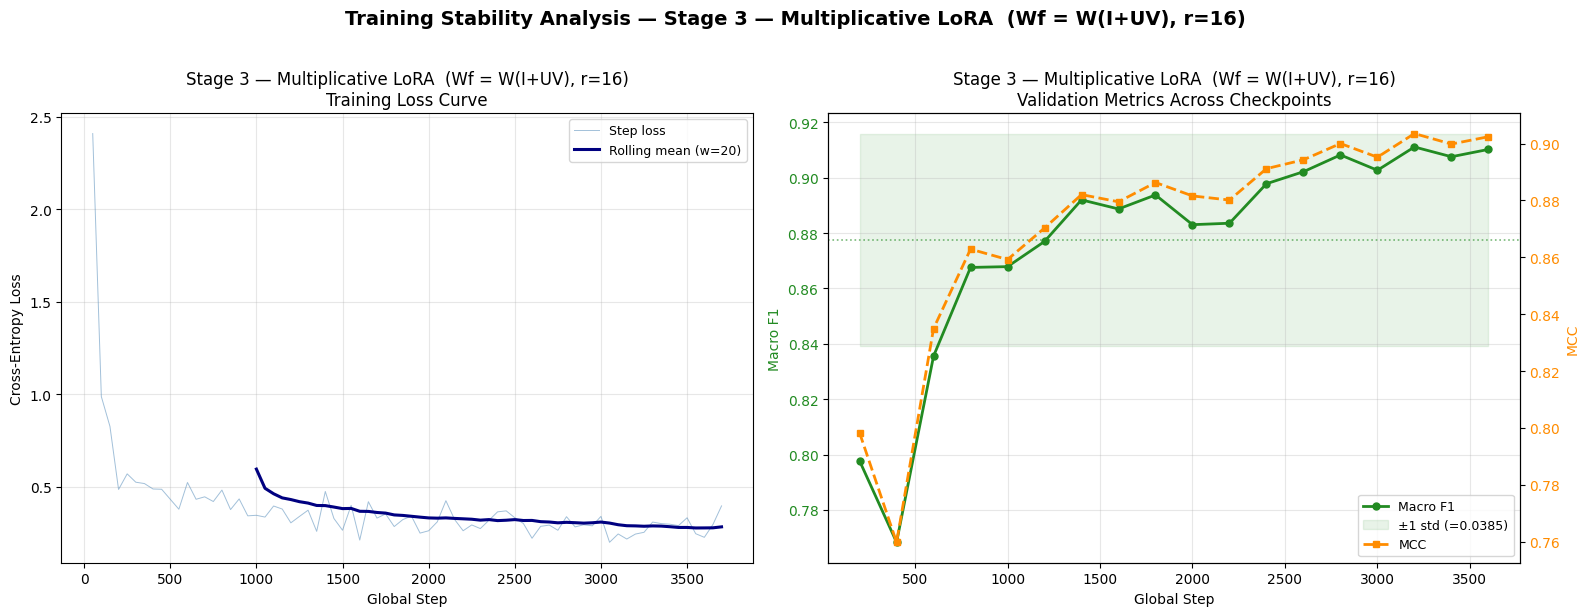

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — MultiplicativeLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9058
  Macro F1          : 0.8942  ← PRIMARY METRIC
  Weighted F1       : 0.9062
  Balanced Accuracy : 0.8945
  MCC               : 0.8866  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7397    0.7542    0.7469      1424
             gender     0.9191    0.8898    0.9042      1788
           religion     0.9625    0.9635    0.9630      1971
          ethnicity     0.9787    0.9879    0.9832      1812
                age     0.9814    0.9723    0.9768      1950
other_cyberbullying     0.7834    0.7993    0.7913      1385

           accuracy                         0.9058     10330
          macro avg     0.8941    0.8945    0.8

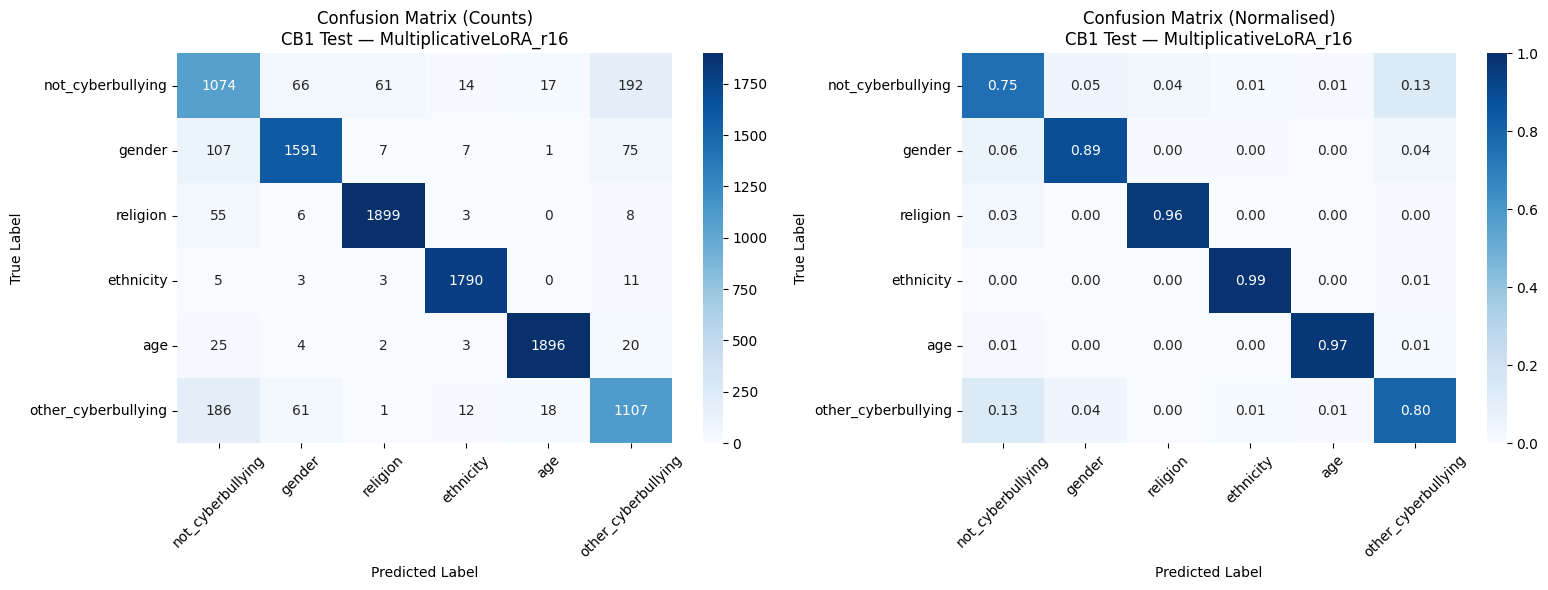


✓ Results saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Gemma2_9B/MultiplicativeLoRA_r16/results_MultiplicativeLoRA_r16.csv
   checkpoint written after r=16  |  elapsed 2.74 h

------------------------------------------------------------
  Rank sweep: r = 32   (2 of 2)
------------------------------------------------------------
✓ All random seeds fixed to 42.

  STAGE 3 — MULTIPLICATIVE LoRA  |  MultiplicativeLoRA_r32
  Model   : google/gemma-2-9b-it
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W(I + UV)   [L2 = 0]
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 256,000
[2] Mapping labels and preparing HF datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

...

   device fix: moved adapters on 168 layers to the frozen-weight device
   PARAMETER AUDIT
     U and V (the actual adapter) : 39,911,424   <-- report THIS as Stage 3 params
     inert PEFT lora_A / lora_B   : 35,804,160   (no gradient, never used in forward)
     counted as trainable         : 75,715,584   (inflated, do not quote)
Class weights (inverse-frequency, normalised):
  [0] not_cyberbullying         1.0000
  [1] gender                    1.0000
  [2] religion                  1.0000
  [3] ethnicity                 1.0000
  [4] age                       1.0000
  [5] other_cyberbullying       1.0000
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,0.530100,0.503159,0.831869,0.801318,0.805831
400,0.462600,0.404544,0.854590,0.843616,0.827155
600,0.609200,0.400463,0.869736,0.851778,0.847508
800,0.507100,0.449581,0.860345,0.829355,0.837147
1000,0.391700,0.448224,0.866404,0.848219,0.844833
1200,0.321500,0.454399,0.885186,0.869069,0.862163
1400,0.462400,0.346101,0.889427,0.876685,0.868576
1600,0.265500,0.360379,0.901545,0.890661,0.881662
1800,0.324900,0.292291,0.904877,0.894255,0.885583
2000,0.317800,0.337548,0.894274,0.877536,0.874663


/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.13/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Training time: 7404s (2.06 hrs)

[5] Computing effective rank of Wf = W(I + UV)...

[6b] Rank-preservation conditions (Proposition 2):
      layers measured      : 168
      max ||UV||_2         : 7.2625   (needs < 1)
      satisfying Prop 2    : 1.2% of layers
      min sigma_min(I+UV)  : 1.5467e-01
      max condition number : 46.75
      NOTE: training left the Proposition 2 regime in some layers.
            Report this. It is a finding, not a failure.
   avg_eff_rank(Wf)  = 2815.98  ← compare to Stage 2 Gemma-2-9B: 2815.98
   avg_eff_rank(UV)  = 32.00  (adapter only, reference)
   LoRA layers       = 168

[6] Generating stability report...
   VALIDATION Macro F1 - best: 0.9131 | final: 0.9122   <-- RANK SELECTION USES THIS, NOT THE TEST SCORE
   Loss CV (overall)   : 0.652580139927335
   Loss std (overall)  : 0.2585910535015842
   Val F1 std          : 0.031774648219094793
   Val MCC std         : 0.02909327393721739
   Composite score     : 0.342177
   Interpretation      : 🔴  Un

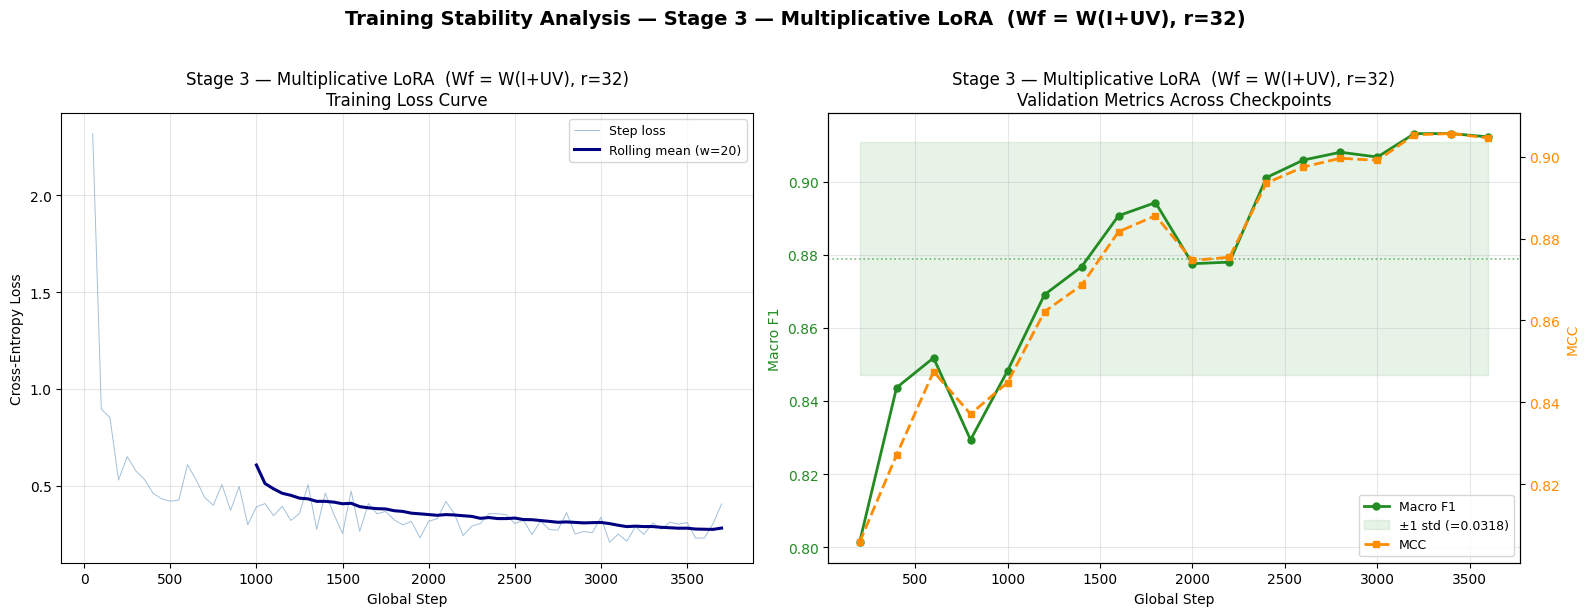

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — MultiplicativeLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9093
  Macro F1          : 0.8972  ← PRIMARY METRIC
  Weighted F1       : 0.9085
  Balanced Accuracy : 0.8974
  MCC               : 0.8908  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7842    0.7170    0.7491      1424
             gender     0.8931    0.9161    0.9045      1788
           religion     0.9574    0.9685    0.9629      1971
          ethnicity     0.9792    0.9879    0.9835      1812
                age     0.9783    0.9723    0.9753      1950
other_cyberbullying     0.7943    0.8224    0.8081      1385

           accuracy                         0.9093     10330
          macro avg     0.8978    0.8974    0.8

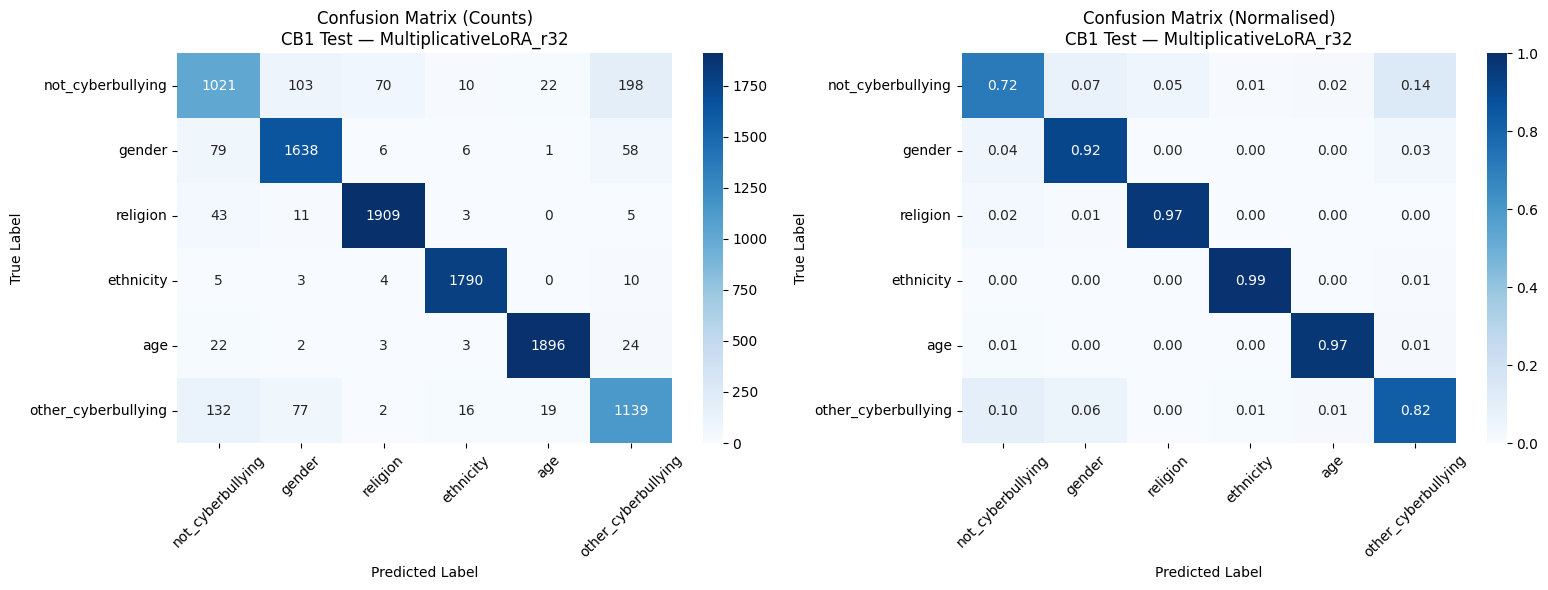


✓ Results saved → /content/drive/MyDrive/Results/CB1_MultiplicativeLoRA_Gemma2_9B/MultiplicativeLoRA_r32/results_MultiplicativeLoRA_r32.csv
   checkpoint written after r=32  |  elapsed 5.52 h

STAGE 3 - CB1 - Gemma-2-9B - MULTIPLICATIVE LoRA - RANK SELECTED ON VALIDATION
   r |   U,V params |  VAL Macro F1 |  TEST Macro F1 |     MCC | selected
   4 |    4,988,928 |        0.9098 |         0.8748 |  0.8629 | 
   8 |    9,977,856 |        0.9107 |         0.8921 |  0.8829 | 
  16 |   19,955,712 |        0.9111 |         0.8942 |  0.8866 | 
  32 |   39,911,424 |        0.9131 |         0.8972 |  0.8908 | <== SELECTED
  (U,V only. The inert PEFT shell is excluded; see the parameter audit above.)

RANK-PRESERVATION DIAGNOSTICS (Proposition 2)
   r |  max ||UV||_2 |  % layers < 1 |  min sigma_min |   max cond |  eff rank
   4 |        1.9501 |          81.0 |     4.2259e-01 |       5.61 |   2815.98
   8 |        3.0147 |          42.9 |     2.9739e-01 |      11.14 |   2815.98
  16 |        

In [11]:
# ═════════════════════════════════════════════════════════════════════════════
#  RANK SWEEP  r in {4, 8, 16, 32}  -- SELECTED ON VALIDATION
#
#
#  This cell is RESUME-SAFE. If the Colab session drops, just run it again:
#  it reloads finished ranks from Drive and trains only what is missing.
#  It only accepts result files that contain val_f1_best, so results from the
#  June runs can never be mixed in with these.
#
#  Runtime: about 12 hours for four runs from cold.
# ═════════════════════════════════════════════════════════════════════════════
import glob, time, os, math

all_rank_results, stale = {}, []
for p in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'MultiplicativeLoRA_r*', 'results_*.csv'))):
    row = pd.read_csv(p).iloc[0].to_dict()
    v = row.get('val_f1_best', None)
    if v is None or (isinstance(v, float) and math.isnan(v)):
        stale.append(int(row['lora_rank'])); continue
    all_rank_results[int(row['lora_rank'])] = row

print('valid, from the patched runs :', sorted(all_rank_results))
print('skipped as stale June files  :', sorted(stale))
missing = [r for r in RANK_SWEEP if r not in all_rank_results]
print('still to run                 :', missing)

_t0 = time.time()
for r in missing:
    print(f'\n{"-"*60}')
    print(f'  Rank sweep: r = {r}   ({missing.index(r)+1} of {len(missing)})')
    print(f'{"-"*60}')
    all_rank_results[r] = run_multiplicative_lora(
        train_df=train_df, val_df=val_df, test_df=test_df,
        lora_rank=r, run_label=f'MultiplicativeLoRA_r{r}')
    pd.DataFrame([{
        'rank': rr,
        'trainable_params': all_rank_results[rr]['trainable_params'],
        'trainable_params_uv_only': all_rank_results[rr].get('trainable_params_uv_only'),
        'val_f1_best':      all_rank_results[rr]['val_f1_best'],
        'test_macro_f1':    all_rank_results[rr]['macro_f1'],
        'test_mcc':         all_rank_results[rr]['mcc'],
        'eff_rank_Wf':      all_rank_results[rr]['avg_eff_rank_Wf'],
        'max_norm_UV':      all_rank_results[rr].get('max_spectral_norm_UV'),
        'frac_prop2':       all_rank_results[rr].get('frac_layers_satisfying_prop2'),
        'min_sigma_min':    all_rank_results[rr].get('min_sigma_min_L1'),
        'max_cond':         all_rank_results[rr].get('max_cond_L1'),
    } for rr in sorted(all_rank_results)]).to_csv(
        os.path.join(OUTPUT_DIR, 'stage3_cb1_rank_sweep_VALIDATION_SELECTED.csv'), index=False)
    print(f'   checkpoint written after r={r}  |  elapsed {(time.time()-_t0)/3600:.2f} h')

# ── selection, on validation only ────────────────────────────────────────────
best_r = max(all_rank_results, key=lambda k: all_rank_results[k]['val_f1_best'])
best   = all_rank_results[best_r]

print('\n' + '='*96)
print('STAGE 3 - CB1 - Gemma-2-9B - MULTIPLICATIVE LoRA - RANK SELECTED ON VALIDATION')
print('='*96)
print(f'{"r":>4} | {"U,V params":>12} | {"VAL Macro F1":>13} | {"TEST Macro F1":>14} | {"MCC":>7} | selected')
for r in sorted(all_rank_results):
    a = all_rank_results[r]
    _p = a.get('trainable_params_uv_only') or a['trainable_params']
    print(f'{r:>4} | {_p:>12,.0f} | {a["val_f1_best"]:>13.4f} | '
          f'{a["macro_f1"]:>14.4f} | {a["mcc"]:>7.4f} | {"<== SELECTED" if r==best_r else ""}')
print('  (U,V only. The inert PEFT shell is excluded; see the parameter audit above.)')
print('='*96)

# ── rank-preservation diagnostics across ranks  ─────────────────
print('\nRANK-PRESERVATION DIAGNOSTICS (Proposition 2)')
print(f'{"r":>4} | {"max ||UV||_2":>13} | {"% layers < 1":>13} | {"min sigma_min":>14} | {"max cond":>10} | {"eff rank":>9}')
for r in sorted(all_rank_results):
    a = all_rank_results[r]
    f = a.get('frac_layers_satisfying_prop2')
    print(f'{r:>4} | {a.get("max_spectral_norm_UV", float("nan")):>13.4f} | '
          f'{(100*f if f is not None else float("nan")):>13.1f} | '
          f'{a.get("min_sigma_min_L1", float("nan")):>14.4e} | '
          f'{a.get("max_cond_L1", float("nan")):>10.2f} | {a["avg_eff_rank_Wf"]:>9.2f}')

# ── cross-stage comparison, all three selected on validation ────────────────
S2 = {'r': 32, 'params': 35_804_160, 'test': 0.9035}   # Stage 2, validation-selected
S4 = {'r':  8, 'params': 18_945_024, 'test': 0.9044}   # Stage 4, validation-selected
print('\n' + '='*96)
print('CROSS-STAGE, EVERY RANK CHOSEN ON VALIDATION')
print('='*96)
print(f'  Stage 2 additive       r={S2["r"]:<3} {S2["params"]:>11,}  test {S2["test"]:.4f}')
_p3 = best.get('trainable_params_uv_only') or best['trainable_params']
print(f'  Stage 3 multiplicative r={best_r:<3} {_p3:>11,.0f}  test {best["macro_f1"]:.4f}')
print(f'  Stage 4 joint          r={S4["r"]:<3} {S4["params"]:>11,}  test {S4["test"]:.4f}')
print(f'\n  Stage 4 minus Stage 3 : {S4["test"] - best["macro_f1"]:+.4f}')
print(f'  Stage 4 minus Stage 2 : {S4["test"] - S2["test"]:+.4f}')
print('\n  Reminder: repeated runs of one configuration differ by about 0.001 Macro F1.')
print('  Treat any gap below roughly 0.002 as indistinguishable from noise.')
print(f'\n>> Selected r={best_r}, test Macro F1 {best["macro_f1"]:.4f}, '
      f'{_p3:,.0f} trainable parameters (U and V only).')


---
## Step 14: Cross-Stage Stability Comparison (Run After All Stages Complete)

**Purpose**: Compare training stability across Stages 2, 3, and 4 for Gemma-2-9B.
**When to run**: After Stage 4 Gemma-2-9B notebook has completed.

Stage 2 Gemma-2-9B was consistently hurt by ICL (few-shot) — known ICL interference characteristic.
LoRA fine-tuning is not affected by this — it was the best Stage 2 CB1 model.


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  Step 14 - Note. Reads the validation-selected run from the sweep instead
#  of results_r16, which no longer exists because Step 12 is disabled.
# ═══════════════════════════════════════════════════════════════════════════
best   = all_rank_results[best_r]
has_cb = isinstance(best, dict) and 'stability_cb' in best

print(f'Stage 3 stability report (validation-selected r={best_r}):')
if has_cb:
    rep = best['stability_cb'].get_stability_report()
    for k in ['loss_cv_overall','loss_std_overall','val_f1_std','val_mcc_std','stability_score']:
        print(f'   {k:<20} : {rep.get(k, "N/A")}')
else:
    print('   (rebuilt from CSV, callback object not available)')
    print(f'   stability_score      : {best.get("stability_score","N/A")}')

print('\n' + '='*70)
print('  STAGE 3 COMPLETE - MULTIPLICATIVE LoRA')
print('  Formula : Wf = W(I + UV)')
print('  Model   : google/gemma-2-9b-it')
print('  Dataset : CB1, 6-class')
print('  Split   : 75/25 stratified, seed 42')
print('='*70)
print(f'\n--- SELECTED ON VALIDATION: r={best_r} ---')
print(f'  Validation Macro F1 : {best["val_f1_best"]:.4f}   <- SELECTION METRIC')
print(f'  Test Macro F1       : {best["macro_f1"]:.4f}   <- reported, not used to select')
print(f'  MCC                 : {best["mcc"]:.4f}')
print(f'  Accuracy            : {best["accuracy"]:.4f}')
print(f'  Trainable params    : {best["trainable_params"]:,.0f}')
print(f'  Eff. rank (Wf)      : {best["avg_eff_rank_Wf"]:.2f}')


Stage 3 stability report (validation-selected r=32):
   loss_cv_overall      : 0.652580139927335
   loss_std_overall     : 0.2585910535015842
   val_f1_std           : 0.031774648219094793
   val_mcc_std          : 0.02909327393721739
   stability_score      : 0.342177

  STAGE 3 COMPLETE - MULTIPLICATIVE LoRA
  Formula : Wf = W(I + UV)
  Model   : google/gemma-2-9b-it
  Dataset : CB1, 6-class
  Split   : 75/25 stratified, seed 42

--- SELECTED ON VALIDATION: r=32 ---
  Validation Macro F1 : 0.9131   <- SELECTION METRIC
  Test Macro F1       : 0.8972   <- reported, not used to select
  MCC                 : 0.8908
  Accuracy            : 0.9093
  Trainable params    : 75,715,584
  Eff. rank (Wf)      : 2815.98
